# Insurance Data Warehouse: Full Medallion Architecture  
## Applying Business Rules from `business_rules.md`

[Business Rules are Defined Here](./business_rules.md)

![](./images/medallion_architecture.png)

---
# What does this notebook do?

### This notebook builds a complete **Bronze → Silver → Gold** <br> pipeline for the messy 4-year insurance dataset.

### Bronze to Silver transformation <br > is done by applying the [Business Rules](./business_rules.md)

---
# INPUT data files...

    
Expected files:

```text
data_messy/insurance.2021.messy.csv
data_messy/insurance.2022.messy.csv
data_messy/insurance.2023.messy.csv
data_messy/insurance.2024.messy.csv
```

---
# Business Rules

## Business Rules Applied

| Rule | Meaning | Silver Action |
|---|---|---|
| Rule 1 | Age must be between 0 and 120 | reject invalid rows |
| Rule 2 | BMI must be between 10 and 60 | reject invalid rows |
| Rule 3 | Charges must be >= 0 | reject invalid rows |
| Rule 4 | Children must be between 0 and 10 | reject invalid rows |
| Rule 5 | Region must be valid after standardization | standardize then validate |
| Rule 6 | Gender and smoker must be valid domains | reject invalid rows |
| Rule 7 | Duplicate records should not exist | deduplicate |
| Rule 8 | Smokers with unusually low charges should be flagged | flag anomaly, do not reject |

---
# Final Goal: Create a STAR SCHEMA

## Final Goal: : Create a STAR SCHEMA

Make the data ready for a **Star Schema**:

- `gold.dim_year`
- `gold.dim_region`
- `gold.dim_person_profile`
- `gold.dim_risk_profile`
- `gold.fact_insurance_charges`

---
# Part 1 — Setup
---

## Cell 01 — Import libraries and connect to DuckDB

### What are we doing?
We import Python libraries and create a DuckDB database connection.

### Why are we doing it?
DuckDB lets us write warehouse-style SQL directly inside a notebook.

### Business value
This creates a reproducible analytical environment.


import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

---
# Make sure that DuckDB is installed:

In [1]:

# Make sure that DuckDB is installed:
try:
    import duckdb
except ImportError:
    %pip install duckdb --quiet
    import duckdb

---
# Install other libraries...

In [2]:
# Install other libraries...
import pandas as pd
import matplotlib.pyplot as plt

---
# Create a CONNECTION object to a DuckDB database

In [3]:
# Create a CONNECTION object to a DuckDB database
con = duckdb.connect("insurance_medallion_dw.duckdb")
print("DuckDB version:", duckdb.__version__)
print("con=", con)

DuckDB version: 1.5.2
con= <_duckdb.DuckDBPyConnection object at 0x1130f2a70>


## Cell 02 — Define source files

### What are we doing?
We define the location of the four messy source files.

### Why are we doing it?
The files represent yearly source-system extracts.

### Business value
Keeping source-year information allows row-level lineage and time-based analysis.


In [4]:
files = {
    2021: "data_messy/insurance.2021.messy.csv",
    2022: "data_messy/insurance.2022.messy.csv",
    2023: "data_messy/insurance.2023.messy.csv",
    2024: "data_messy/insurance.2024.messy.csv",
}

files

{2021: 'data_messy/insurance.2021.messy.csv',
 2022: 'data_messy/insurance.2022.messy.csv',
 2023: 'data_messy/insurance.2023.messy.csv',
 2024: 'data_messy/insurance.2024.messy.csv'}

## Cell 03 — Create Medallion schemas

### What are we doing?
We create three schemas: `bronze`, `silver`, and `gold`.

### Why are we doing it?
Each schema has a different responsibility.

### Business value
This separates raw data, trusted data, and analytics-ready data.


In [5]:
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")

con.execute("""
SELECT schema_name
FROM information_schema.schemata
WHERE schema_name IN ('bronze', 'silver', 'gold')
ORDER BY schema_name;
""").df()

,schema_name
0,bronze
1,gold
2,silver


---
# Part 2 — Bronze Layer: Raw Ingestion
---

## Cell 04 — Load messy CSV files into Bronze

### What are we doing?
We load each yearly messy CSV file into a Bronze table.

### Why are we doing it?
Bronze should preserve raw data as close to the source as possible.

### Business value
If something goes wrong downstream, we can trace back to the original row.

### Business rules solved
None yet. Bronze does **not** clean data.


In [6]:
for year, path in files.items():
    con.execute(f"""
    CREATE OR REPLACE TABLE bronze.insurance_{year}_raw AS
    SELECT
        {year} AS source_year,
        '{path}' AS source_file,
        ROW_NUMBER() OVER () AS raw_row_id,
        *
    FROM read_csv_auto('{path}', header=true, all_varchar=true);
    """)

con.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bronze'
ORDER BY table_name;
""").df()

,table_name
0,insurance_2021_raw
1,insurance_2022_raw
2,insurance_2023_raw
3,insurance_2024_raw


## Cell 05 — Combine yearly Bronze tables

### What are we doing?
We union all yearly Bronze tables into one `bronze.insurance_raw` table.

### Why are we doing it?
A single Bronze table makes cross-year profiling and downstream transformation easier.

### Business value
We get one consistent raw landing table with full lineage.

### Business rules solved
None yet. This is still raw data.


In [7]:
con.execute("""
CREATE OR REPLACE TABLE bronze.insurance_raw AS
SELECT * FROM bronze.insurance_2021_raw
UNION ALL
SELECT * FROM bronze.insurance_2022_raw
UNION ALL
SELECT * FROM bronze.insurance_2023_raw
UNION ALL
SELECT * FROM bronze.insurance_2024_raw;
""")

con.execute("""
SELECT
    source_year,
    COUNT(*) AS bronze_rows
FROM bronze.insurance_raw
GROUP BY source_year
ORDER BY source_year;
""").df()

,source_year,bronze_rows
0,2021,1602
1,2022,1443
2,2023,1615
3,2024,1807


## Cell 06 — Preview Bronze data

### What are we doing?
We look at raw records.

### Why are we doing it?
Before transforming data, we need to see what values look like.

### Business value
Students see why Bronze cannot be trusted directly.


In [8]:
con.execute("""
SELECT *
FROM bronze.insurance_raw
ORDER BY source_year, raw_row_id
LIMIT 12;
""").df()

,source_year,source_file,raw_row_id,age,gender,bmi,children,smoker,region,charges
0,2021,data_messy/insurance.2021.messy.csv,1,42.0,female,40.17,4.0,no,northwest,18902.47
1,2021,data_messy/insurance.2021.messy.csv,2,57.0,female,44.85,1.0,no,northwest,20917.45
2,2021,data_messy/insurance.2021.messy.csv,3,49.0,female,36.38,0.0,no,northeast,18021.33
3,2021,data_messy/insurance.2021.messy.csv,4,47.0,male,31.11,0.0,no,southwest,8580.46
4,2021,data_messy/insurance.2021.messy.csv,5,61.0,female,29.28,1.0,no,southeast,25497.6
5,2021,data_messy/insurance.2021.messy.csv,6,57.0,male,35.91,0.0,yes,north,34998.76
6,2021,data_messy/insurance.2021.messy.csv,7,44.0,female,31.78,4.0,no,northwest,15025.69
7,2021,data_messy/insurance.2021.messy.csv,8,56.0,female,5.0,1.0,no,southwest,23159.42
8,2021,data_messy/insurance.2021.messy.csv,9,49.0,male,15.5,2.0,no,northwest,13653.04
9,2021,data_messy/insurance.2021.messy.csv,10,33.0,female,33.76,2.0,no,southwest,7415.0


---
# Part 3 — Silver Reference Table
---

## Cell 07 — Create valid region reference table

### What are we doing?
We create `silver.dim_valid_region`.

### Why are we doing it?
Valid business regions should be defined once, not hardcoded everywhere.

### Business value
This supports governance and makes region validation reusable.

### Business rule solved
Rule 5 — Region must be valid after standardization.


In [9]:
con.execute("""
CREATE OR REPLACE TABLE silver.dim_valid_region AS
SELECT *
FROM (VALUES
    ('northeast'),
    ('northwest'),
    ('southeast'),
    ('southwest'),
    ('midwest'),
    ('north'),
    ('south')
) AS t(region);
""")

con.execute("""
SELECT *
FROM silver.dim_valid_region
ORDER BY region;
""").df()

,region
0,midwest
1,north
2,northeast
3,northwest
4,south
5,southeast
6,southwest


---
# Part 4 — Silver Step 01: Deduplication
---

## Cell 08 — Deduplicate raw data

### What are we doing?
We remove exact duplicate records from Bronze.

### Why are we doing it?
Duplicates inflate row counts and distort metrics such as average charges.

### Business value
This prevents duplicated records from corrupting KPIs.

### Business rule solved
Rule 7 — Duplicate records should not exist.


In [10]:
con.execute("""
CREATE OR REPLACE TABLE silver.step01_dedup AS
SELECT *
FROM (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY
                source_year,
                age,
                gender,
                bmi,
                children,
                smoker,
                region,
                charges
            ORDER BY raw_row_id
        ) AS rn
    FROM bronze.insurance_raw
)
WHERE rn = 1;
""")

con.execute("""
SELECT
    (SELECT COUNT(*) FROM bronze.insurance_raw) AS bronze_rows,
    (SELECT COUNT(*) FROM silver.step01_dedup) AS dedup_rows,
    (SELECT COUNT(*) FROM bronze.insurance_raw) -
    (SELECT COUNT(*) FROM silver.step01_dedup) AS removed_duplicate_rows;
""").df()

,bronze_rows,dedup_rows,removed_duplicate_rows
0,6467,6180,287


## Cell 09 — Plot Bronze vs Dedup rows

### What are we doing?
We visualize row counts before and after deduplication.

### Why are we doing it?
Students can see the impact of Rule 7.

### Business value
A simple funnel builds confidence that the pipeline is improving data quality.


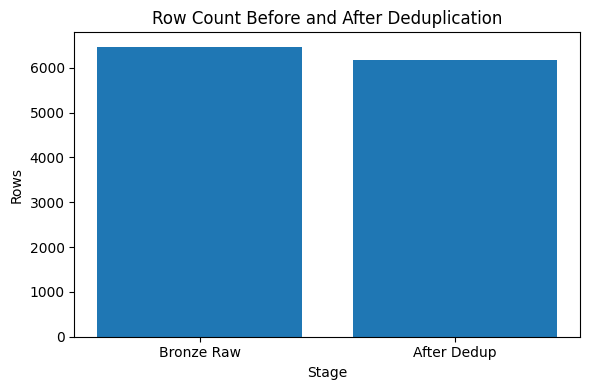

,stage,row_count
0,Bronze Raw,6467
1,After Dedup,6180


In [11]:
df_dedup = con.execute("""
SELECT 'Bronze Raw' AS stage, COUNT(*) AS row_count FROM bronze.insurance_raw
UNION ALL
SELECT 'After Dedup', COUNT(*) FROM silver.step01_dedup;
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_dedup["stage"], df_dedup["row_count"])
plt.title("Row Count Before and After Deduplication")
plt.xlabel("Stage")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

df_dedup

---
# Part 5 — Silver Step 02: Standardization and Safe Typing
---

## Cell 10 — Standardize and type raw values

### What are we doing?
We create `silver.step02_standardized`.

This step:
- trims text
- lowercases categorical values
- safely casts numeric fields
- standardizes regions by removing spaces and hyphens

### Why are we doing it?
Raw text values cannot be reliably validated or analyzed.

### Business value
This prepares data for rule validation without losing original raw values.

### Business rules solved
Prepares for Rules 1–6 and Rule 8.


In [12]:
con.execute("""
CREATE OR REPLACE TABLE silver.step02_standardized AS
SELECT
    source_year,
    source_file,
    raw_row_id,

    -- Raw values preserved for audit
    age AS age_raw,
    gender AS gender_raw,
    bmi AS bmi_raw,
    children AS children_raw,
    smoker AS smoker_raw,
    region AS region_raw,
    charges AS charges_raw,

    -- Typed / cleaned values
    TRY_CAST(NULLIF(TRIM(age), '') AS INTEGER) AS age,
    LOWER(NULLIF(TRIM(gender), '')) AS gender,
    TRY_CAST(NULLIF(TRIM(bmi), '') AS DOUBLE) AS bmi,
    TRY_CAST(NULLIF(TRIM(children), '') AS INTEGER) AS children,
    LOWER(NULLIF(TRIM(smoker), '')) AS smoker,

    -- Region standardization: trim, lowercase, remove spaces, remove hyphens
    REPLACE(
        REPLACE(LOWER(TRIM(region)), ' ', ''),
        '-', ''
    ) AS region,

    TRY_CAST(NULLIF(TRIM(charges), '') AS DOUBLE) AS charges

FROM silver.step01_dedup;
""")

con.execute("""
SELECT *
FROM silver.step02_standardized
LIMIT 10;
""").df()

,source_year,source_file,raw_row_id,age_raw,gender_raw,bmi_raw,children_raw,smoker_raw,region_raw,charges_raw,age,gender,bmi,children,smoker,region,charges
0,2021,data_messy/insurance.2021.messy.csv,1,42.0,female,40.17,4.0,no,northwest,18902.47,42,female,40.17,4,no,northwest,18902.47
1,2021,data_messy/insurance.2021.messy.csv,2,57.0,female,44.85,1.0,no,northwest,20917.45,57,female,44.85,1,no,northwest,20917.45
2,2021,data_messy/insurance.2021.messy.csv,3,49.0,female,36.38,0.0,no,northeast,18021.33,49,female,36.38,0,no,northeast,18021.33
3,2021,data_messy/insurance.2021.messy.csv,4,47.0,male,31.11,0.0,no,southwest,8580.46,47,male,31.11,0,no,southwest,8580.46
4,2021,data_messy/insurance.2021.messy.csv,5,61.0,female,29.28,1.0,no,southeast,25497.6,61,female,29.28,1,no,southeast,25497.60
5,2021,data_messy/insurance.2021.messy.csv,6,57.0,male,35.91,0.0,yes,north,34998.76,57,male,35.91,0,yes,north,34998.76
6,2021,data_messy/insurance.2021.messy.csv,7,44.0,female,31.78,4.0,no,northwest,15025.69,44,female,31.78,4,no,northwest,15025.69
7,2021,data_messy/insurance.2021.messy.csv,8,56.0,female,5.0,1.0,no,southwest,23159.42,56,female,5.00,1,no,southwest,23159.42
8,2021,data_messy/insurance.2021.messy.csv,9,49.0,male,15.5,2.0,no,northwest,13653.04,49,male,15.50,2,no,northwest,13653.04
9,2021,data_messy/insurance.2021.messy.csv,10,33.0,female,33.76,2.0,no,southwest,7415.0,33,female,33.76,2,no,southwest,7415.00


In [13]:
con.execute("""
SELECT
    COUNT(*) AS both_bmi_and_charges
FROM silver.step02_standardized
WHERE
    (bmi IS NULL OR bmi < 10 OR bmi > 60)
AND
    (charges IS NULL OR charges < 0);
""").df()

,both_bmi_and_charges
0,39


In [14]:
con.execute("""
SELECT
    'BMI only' AS category,
    COUNT(*) AS rows
FROM silver.step02_standardized
WHERE
    (bmi IS NULL OR bmi < 10 OR bmi > 60)
AND NOT (charges IS NULL OR charges < 0)

UNION ALL

SELECT
    'Charges only',
    COUNT(*)
FROM silver.step02_standardized
WHERE
    (charges IS NULL OR charges < 0)
AND NOT (bmi IS NULL OR bmi < 10 OR bmi > 60)

UNION ALL

SELECT
    'Both',
    COUNT(*)
FROM silver.step02_standardized
WHERE
    (bmi IS NULL OR bmi < 10 OR bmi > 60)
AND
    (charges IS NULL OR charges < 0);
""").df()

,category,rows
0,BMI only,254
1,Charges only,254
2,Both,39


---
# Teaching Gold Question

```
Ask students:

“Why is ‘Both’ much smaller than individual categories?”

Expected answer:
Because errors are mostly independent,

not caused by a single upstream failure.
```

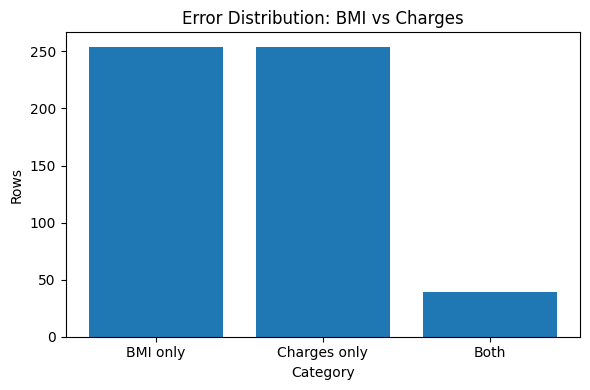

In [15]:
df = con.execute("""
SELECT
    category,
    rows
FROM (
    SELECT 'BMI only' AS category, 254 AS rows
    UNION ALL
    SELECT 'Charges only', 254
    UNION ALL
    SELECT 'Both', 39
)
""").df()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(df["category"], df["rows"])
plt.title("Error Distribution: BMI vs Charges")
plt.xlabel("Category")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## Cell 11 — Show region standardization examples

### What are we doing?
We compare raw regions to standardized regions.

### Why are we doing it?
Region data can be messy without being truly invalid.

### Business value
This teaches the difference between formatting issues and invalid business values.

### Business rule solved
Rule 5 — Region standardization.


In [16]:
con.execute("""
SELECT
    region_raw,
    region AS region_standardized,
    COUNT(*) AS row_count
FROM silver.step02_standardized
GROUP BY region_raw, region
ORDER BY row_count DESC, region_raw
LIMIT 30;
""").df()

,region_raw,region_standardized,row_count
0,southeast,southeast,1459
1,northwest,northwest,1271
2,northeast,northeast,1133
3,southwest,southwest,1111
4,south,south,389
5,midwest,midwest,282
6,north,north,212
7,unknown,unknown,42
8,north-east,northeast,40
9,SOUTHWEST,southwest,38


---
# Part 6 — Silver Step 03: Rejected Records
---

## Cell 12 — Create rejected records table

### What are we doing?
We create `silver.rejected_records` with a rejection reason.

### Why are we doing it?
Bad records should not silently disappear. We preserve them for auditing.

### Business value
Rejected records help identify upstream data-quality problems.

### Business rules solved
Rules 1–6.


In [17]:
con.execute("""
SELECT
    COUNT(*) FILTER (WHERE bmi IS NULL OR bmi < 10 OR bmi > 60) AS invalid_bmi,
    COUNT(*) FILTER (WHERE charges IS NULL OR charges < 0) AS invalid_charges,
    COUNT(*) FILTER (WHERE gender NOT IN ('male','female')) AS invalid_gender,
    COUNT(*) FILTER (WHERE smoker NOT IN ('yes','no')) AS invalid_smoker,
    COUNT(*) FILTER (WHERE v.region IS NULL) AS invalid_region
FROM silver.step02_standardized s
LEFT JOIN silver.dim_valid_region v
    ON s.region = v.region;
""").df()

,invalid_bmi,invalid_charges,invalid_gender,invalid_smoker,invalid_region
0,293,293,141,159,117


In [18]:
con.execute("""
CREATE OR REPLACE TABLE silver.rejected_records AS
WITH base AS (
    SELECT
        s.*,
        v.region AS valid_region,

        -- Individual rule flags (0/1)
        CASE WHEN age IS NULL OR age < 0 OR age > 120 THEN 1 ELSE 0 END AS f_invalid_age,
        CASE WHEN bmi IS NULL OR bmi < 10 OR bmi > 60 THEN 1 ELSE 0 END AS f_invalid_bmi,
        CASE WHEN charges IS NULL OR charges < 0 THEN 1 ELSE 0 END AS f_invalid_charges,
        CASE WHEN children IS NULL OR children < 0 OR children > 10 THEN 1 ELSE 0 END AS f_invalid_children,
        CASE WHEN gender IS NULL OR gender NOT IN ('male','female') THEN 1 ELSE 0 END AS f_invalid_gender,
        CASE WHEN smoker IS NULL OR smoker NOT IN ('yes','no') THEN 1 ELSE 0 END AS f_invalid_smoker,
        CASE WHEN v.region IS NULL THEN 1 ELSE 0 END AS f_invalid_region

    FROM silver.step02_standardized s
    LEFT JOIN silver.dim_valid_region v
        ON s.region = v.region
)

SELECT
    *,

    -- Total number of violations per row
    (
        f_invalid_age +
        f_invalid_bmi +
        f_invalid_charges +
        f_invalid_children +
        f_invalid_gender +
        f_invalid_smoker +
        f_invalid_region
    ) AS total_violations,

    -- Concatenate ALL violations into a readable string
    CONCAT_WS('|',
        CASE WHEN f_invalid_age = 1 THEN 'INVALID_AGE' END,
        CASE WHEN f_invalid_bmi = 1 THEN 'INVALID_BMI' END,
        CASE WHEN f_invalid_charges = 1 THEN 'INVALID_CHARGES' END,
        CASE WHEN f_invalid_children = 1 THEN 'INVALID_CHILDREN' END,
        CASE WHEN f_invalid_gender = 1 THEN 'INVALID_GENDER' END,
        CASE WHEN f_invalid_smoker = 1 THEN 'INVALID_SMOKER' END,
        CASE WHEN f_invalid_region = 1 THEN 'INVALID_REGION' END
    ) AS reject_reasons

FROM base

-- Only keep rows that violate at least one rule
WHERE
    (
        f_invalid_age +
        f_invalid_bmi +
        f_invalid_charges +
        f_invalid_children +
        f_invalid_gender +
        f_invalid_smoker +
        f_invalid_region
    ) > 0;
""")

con.execute("""
SELECT
    reject_reasons,
    COUNT(*) AS rejected_rows
FROM silver.rejected_records
GROUP BY reject_reasons
ORDER BY rejected_rows DESC;
""").df()

,reject_reasons,rejected_rows
0,INVALID_SMOKER,154
1,INVALID_CHILDREN,150
2,INVALID_CHARGES,140
3,INVALID_AGE,135
4,INVALID_GENDER,133
...,...,...
57,INVALID_CHILDREN|INVALID_REGION,2
58,INVALID_BMI|INVALID_CHARGES|INVALID_GENDER,2
59,INVALID_BMI|INVALID_SMOKER|INVALID_REGION,1
60,INVALID_AGE|INVALID_GENDER|INVALID_REGION,1


In [19]:
con.execute("""
SELECT
    total_violations,
    COUNT(*) AS rows
FROM silver.rejected_records
GROUP BY total_violations
ORDER BY total_violations DESC;
""").df()

,total_violations,rows
0,3,184
1,2,271
2,1,882


## Cell 13 — Plot rejected records by reason

### What are we doing?
We visualize rejection counts.

### Why are we doing it?
This shows which rules are causing the most data loss.

### Business value
The business can prioritize fixing the most common upstream problems.


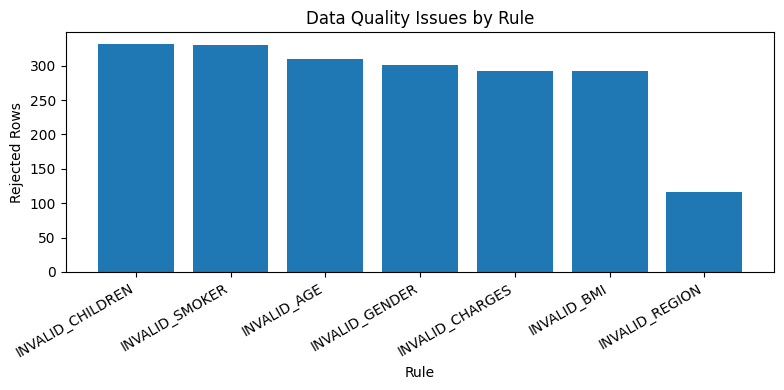

In [20]:
df_rules = con.execute("""
SELECT
    rule,
    COUNT(*) AS rows
FROM (
    SELECT
        UNNEST(string_split(reject_reasons, '|')) AS rule
    FROM silver.rejected_records
) t
GROUP BY rule
ORDER BY rows DESC;
""").df()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(df_rules["rule"], df_rules["rows"])
plt.title("Data Quality Issues by Rule")
plt.xlabel("Rule")
plt.ylabel("Rejected Rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 14 — Inspect invalid region records

### What are we doing?
We inspect region values that failed validation.

### Why are we doing it?
This confirms formatting issues were fixed but truly invalid values remain rejected.

### Business value
This proves the region business rule is working correctly.


In [21]:
con.execute("""

SELECT

    region_raw,

    region AS region_standardized,

    COUNT(*) AS row_count

FROM silver.rejected_records

WHERE reject_reasons LIKE '%INVALID_REGION%'

GROUP BY region_raw, region

ORDER BY row_count DESC;

""").df()

,region_raw,region_standardized,row_count
0,unknown,unknown,42
1,mars,mars,38
2,moon,moon,37


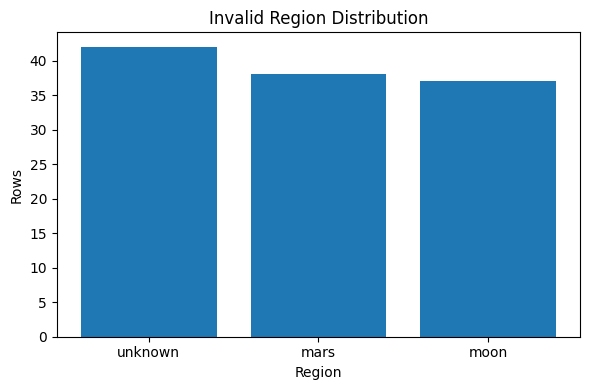

In [22]:
df_region = con.execute("""

SELECT

    region AS region_standardized,

    COUNT(*) AS rows

FROM silver.rejected_records,

     UNNEST(string_split(reject_reasons, '|')) AS t(rule)

WHERE rule = 'INVALID_REGION'

GROUP BY region

ORDER BY rows DESC;

""").df()


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(df_region["region_standardized"], df_region["rows"])

plt.title("Invalid Region Distribution")

plt.xlabel("Region")

plt.ylabel("Rows")

plt.tight_layout()

plt.show()

---
# Part 7 — Silver Clean and Enriched Tables
---

## Cell 15 — Create Silver clean table

### What are we doing?
We create `silver.insurance_clean` with valid records only.

### Why are we doing it?
This is the trusted dataset that can feed analytics and Gold tables.

### Business value
Only validated, standardized data should flow into dashboards and reports.

### Business rules solved
Rules 1–7 are enforced.


In [23]:
con.execute("""
CREATE OR REPLACE TABLE silver.insurance_clean AS
SELECT DISTINCT
    s.source_year,
    s.source_file,
    s.raw_row_id,
    s.age,
    s.gender,
    s.bmi,
    s.children,
    s.smoker,
    s.region,
    s.charges

FROM silver.step02_standardized s
JOIN silver.dim_valid_region v
    ON s.region = v.region

WHERE s.age BETWEEN 0 AND 120
  AND s.bmi BETWEEN 10 AND 60
  AND s.charges >= 0
  AND s.children BETWEEN 0 AND 10
  AND s.gender IN ('male', 'female')
  AND s.smoker IN ('yes', 'no');
""")

con.execute("""
SELECT
    (SELECT COUNT(*) FROM bronze.insurance_raw) AS bronze_rows,
    (SELECT COUNT(*) FROM silver.step01_dedup) AS dedup_rows,
    (SELECT COUNT(*) FROM silver.rejected_records) AS rejected_rows,
    (SELECT COUNT(*) FROM silver.insurance_clean) AS clean_rows;
""").df()

,bronze_rows,dedup_rows,rejected_rows,clean_rows
0,6467,6180,1337,4843


In [24]:
# KPI
con.execute("""
SELECT
    ROUND(100.0 * rejected_rows / dedup_rows, 2) AS rejection_rate_pct,
    ROUND(100.0 * clean_rows / dedup_rows, 2) AS clean_rate_pct
FROM (
    SELECT
        (SELECT COUNT(*) FROM silver.step01_dedup) AS dedup_rows,
        (SELECT COUNT(*) FROM silver.rejected_records) AS rejected_rows,
        (SELECT COUNT(*) FROM silver.insurance_clean) AS clean_rows
);
""").df()

,rejection_rate_pct,clean_rate_pct
0,21.63,78.37


In [25]:
con.execute("""
SELECT
    smoker,
    MIN(charges),
    MAX(charges),
    AVG(charges)
FROM silver.insurance_clean
GROUP BY smoker;
""").df()

,smoker,min(charges),max(charges),avg(charges)
0,yes,14753.15,61974.25,37168.419059
1,no,200.00,41441.83,12274.976180


## Cell 16 — Pipeline funnel

### What are we doing?
We show row counts across Bronze and Silver stages.

### Why are we doing it?
This shows the impact of each transformation stage.

### Business value
A row-count funnel is a useful governance and audit artifact.


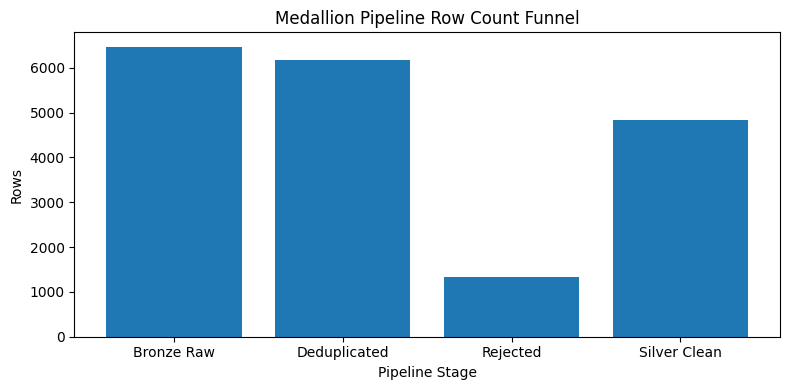

,stage,row_count
0,Bronze Raw,6467
1,Deduplicated,6180
2,Rejected,1337
3,Silver Clean,4843


In [26]:
df_funnel = con.execute("""
SELECT 'Bronze Raw' AS stage, COUNT(*) AS row_count FROM bronze.insurance_raw
UNION ALL
SELECT 'Deduplicated', COUNT(*) FROM silver.step01_dedup
UNION ALL
SELECT 'Rejected', COUNT(*) FROM silver.rejected_records
UNION ALL
SELECT 'Silver Clean', COUNT(*) FROM silver.insurance_clean;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_funnel["stage"], df_funnel["row_count"])
plt.title("Medallion Pipeline Row Count Funnel")
plt.xlabel("Pipeline Stage")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

df_funnel

## Cell 17 — Create enriched Silver table

### What are we doing?
We add:
- `age_group`
- `bmi_group`
- `semantic_low_charge_smoker_flag`

### Why are we doing it?
Gold dimensions and dashboards need business-friendly categories.

### Business value
This makes the data ready for star schema modeling.

### Business rule solved
Rule 8 — Smokers with unusually low charges are flagged, not rejected.


In [27]:
con.execute("""
CREATE OR REPLACE TABLE silver.insurance_enriched AS
WITH smoker_threshold AS (
    -- Compute a data-driven threshold (10th percentile for smokers)
    SELECT
        PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY charges) AS p10_smoker_charges
    FROM silver.insurance_clean
    WHERE smoker = 'yes'
)

SELECT
    -- Core columns
    source_year,
    source_file,
    raw_row_id,

    age,
    gender,
    bmi,
    children,
    smoker,
    region,
    charges,

    -- -----------------------------------
    -- Derived: Age Group
    -- -----------------------------------
    CASE
        WHEN age < 20 THEN 'under_20'
        WHEN age BETWEEN 20 AND 29 THEN '20s'
        WHEN age BETWEEN 30 AND 39 THEN '30s'
        WHEN age BETWEEN 40 AND 49 THEN '40s'
        WHEN age BETWEEN 50 AND 59 THEN '50s'
        WHEN age BETWEEN 60 AND 69 THEN '60s'
        ELSE '70_plus'
    END AS age_group,

    -- -----------------------------------
    -- Derived: BMI Group
    -- -----------------------------------
    CASE
        WHEN bmi < 18.5 THEN 'underweight'
        WHEN bmi < 25 THEN 'normal'
        WHEN bmi < 30 THEN 'overweight'
        ELSE 'obese'
    END AS bmi_group,

    -- -----------------------------------
    -- Derived: Semantic Feature (FIXED ✅)
    -- -----------------------------------
    CASE
        WHEN smoker = 'yes'
         AND charges < (SELECT p10_smoker_charges FROM smoker_threshold)
        THEN 1
        ELSE 0
    END AS semantic_low_charge_smoker_flag

FROM silver.insurance_clean;
""").df()

con.execute("""
SELECT * 
FROM silver.insurance_enriched 
LIMIT 15;
""").df()

,source_year,source_file,raw_row_id,age,gender,bmi,children,smoker,region,charges,age_group,bmi_group,semantic_low_charge_smoker_flag
0,2021,data_messy/insurance.2021.messy.csv,1,42,female,40.17,4,no,northwest,18902.47,40s,obese,0
1,2021,data_messy/insurance.2021.messy.csv,14,40,female,36.57,0,yes,north,33185.36,40s,obese,0
2,2021,data_messy/insurance.2021.messy.csv,35,39,female,30.66,2,no,northwest,13282.72,30s,obese,0
3,2021,data_messy/insurance.2021.messy.csv,55,29,female,16.81,0,yes,southwest,28114.99,20s,underweight,0
4,2021,data_messy/insurance.2021.messy.csv,82,43,male,31.28,0,no,northeast,11754.75,40s,obese,0
5,2021,data_messy/insurance.2021.messy.csv,100,50,male,30.01,2,no,northwest,8130.45,50s,obese,0
6,2021,data_messy/insurance.2021.messy.csv,112,62,male,28.72,0,yes,north,43402.52,60s,overweight,0
7,2021,data_messy/insurance.2021.messy.csv,123,61,male,25.82,0,no,southeast,15412.50,60s,overweight,0
8,2021,data_messy/insurance.2021.messy.csv,139,31,female,37.59,4,no,northwest,14171.09,30s,obese,0
9,2021,data_messy/insurance.2021.messy.csv,157,64,male,35.07,2,no,southeast,11294.62,60s,obese,0


## Cell 18 — Semantic anomaly count

### What are we doing?
We count smoker records with unusually low charges.

### Why are we doing it?
These records are not necessarily invalid, but they are suspicious.

### Business value
Flagging preserves data while alerting analysts to possible anomalies.


In [28]:
con.execute("""
SELECT
    semantic_low_charge_smoker_flag,
    COUNT(*) AS row_count
FROM silver.insurance_enriched
GROUP BY semantic_low_charge_smoker_flag
ORDER BY semantic_low_charge_smoker_flag;
""").df()

,semantic_low_charge_smoker_flag,row_count
0,0,4721
1,1,122


---
# Part 8 — Gold Layer: Star Schema Ready Tables
---

## Cell 19 — Create Gold dimension: dim_year

### What are we doing?
We create a small year dimension.

### Why are we doing it?
Year is a common analytical slice.

### Business value
Supports year-over-year reporting.


In [29]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_year AS
SELECT
    ROW_NUMBER() OVER (ORDER BY source_year) AS year_key,
    source_year
FROM (
    SELECT DISTINCT source_year
    FROM silver.insurance_enriched
);
""")

con.execute("""
SELECT *
FROM gold.dim_year
ORDER BY year_key;
""").df()

,year_key,source_year
0,1,2021
1,2,2022
2,3,2023
3,4,2024


## Cell 20 — Create Gold dimension: dim_region

### What are we doing?
We create a region dimension from clean Silver data.

### Why are we doing it?
Region is a business dimension for geographic analysis.

### Business value
Enables regional cost reporting and comparison.


In [30]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_region AS
SELECT
    ROW_NUMBER() OVER (ORDER BY region) AS region_key,
    region
FROM (
    SELECT DISTINCT region
    FROM silver.insurance_enriched
);
""")

con.execute("""
SELECT *
FROM gold.dim_region
ORDER BY region_key;
""").df()

,region_key,region
0,1,midwest
1,2,north
2,3,northeast
3,4,northwest
4,5,south
5,6,southeast
6,7,southwest


## Cell 21 — Create Gold dimension: dim_person_profile

### What are we doing?
We create a dimension for demographic and family attributes.

### Why are we doing it?
Age group, gender, and children are descriptive attributes used for slicing facts.

### Business value
Supports demographic analysis of insurance charges.


In [31]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_person_profile AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY gender, age_group, children
    ) AS person_profile_key,
    gender,
    age_group,
    children
FROM (
    SELECT DISTINCT
        gender,
        age_group,
        children
    FROM silver.insurance_enriched
);
""")

con.execute("""
SELECT *
FROM gold.dim_person_profile
ORDER BY person_profile_key
LIMIT 20;
""").df()

,person_profile_key,gender,age_group,children
0,1,female,20s,0
1,2,female,20s,1
2,3,female,20s,2
3,4,female,20s,3
4,5,female,20s,4
5,6,female,20s,5
6,7,female,30s,0
7,8,female,30s,1
8,9,female,30s,2
9,10,female,30s,3


## Cell 22 — Create Gold dimension: dim_risk_profile

### What are we doing?
We create a dimension for risk-related attributes.

### Why are we doing it?
Smoker status and BMI group are risk indicators.

### Business value
Supports risk-based cost analysis.


In [32]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_risk_profile AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY smoker, bmi_group, semantic_low_charge_smoker_flag
    ) AS risk_profile_key,
    smoker,
    bmi_group,
    semantic_low_charge_smoker_flag
FROM (
    SELECT DISTINCT
        smoker,
        bmi_group,
        semantic_low_charge_smoker_flag
    FROM silver.insurance_enriched
);
""")

con.execute("""
SELECT *
FROM gold.dim_risk_profile
ORDER BY risk_profile_key;
""").df()

,risk_profile_key,smoker,bmi_group,semantic_low_charge_smoker_flag
0,1,no,normal,0
1,2,no,obese,0
2,3,no,overweight,0
3,4,no,underweight,0
4,5,yes,normal,0
5,6,yes,normal,1
6,7,yes,obese,0
7,8,yes,obese,1
8,9,yes,overweight,0
9,10,yes,overweight,1


## Cell 23 — Create Gold fact table

### What are we doing?
We create `gold.fact_insurance_charges`.

### Why are we doing it?
The fact table stores measurable insurance events and foreign keys to dimensions.

### Business value
This is the analytics-ready star schema foundation.


In [33]:
con.execute("""
CREATE OR REPLACE TABLE gold.fact_insurance_charges AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY e.source_year, e.raw_row_id
    ) AS insurance_fact_key,

    y.year_key,
    r.region_key,
    p.person_profile_key,
    rp.risk_profile_key,

    -- Degenerate / traceability fields
    e.source_year,
    e.raw_row_id,

    -- Measures
    e.age,
    e.bmi,
    e.charges

FROM silver.insurance_enriched e

JOIN gold.dim_year y
    ON e.source_year = y.source_year

JOIN gold.dim_region r
    ON e.region = r.region

JOIN gold.dim_person_profile p
    ON e.gender = p.gender
   AND e.age_group = p.age_group
   AND e.children = p.children

JOIN gold.dim_risk_profile rp
    ON e.smoker = rp.smoker
   AND e.bmi_group = rp.bmi_group
   AND e.semantic_low_charge_smoker_flag = rp.semantic_low_charge_smoker_flag;
""")

con.execute("""
SELECT *
FROM gold.fact_insurance_charges
LIMIT 15;
""").df()

,insurance_fact_key,year_key,region_key,person_profile_key,risk_profile_key,source_year,raw_row_id,age,bmi,charges
0,1,1,4,17,2,2021,1,42,40.17,18902.47
1,2,1,4,20,2,2021,2,57,44.85,20917.45
2,3,1,3,13,2,2021,3,49,36.38,18021.33
3,4,1,7,49,2,2021,4,47,31.11,8580.46
4,5,1,6,26,3,2021,5,61,29.28,25497.60
5,6,1,2,55,7,2021,6,57,35.91,34998.76
6,7,1,4,17,2,2021,7,44,31.78,15025.69
7,8,1,4,51,4,2021,9,49,15.50,13653.04
8,9,1,7,9,2,2021,10,33,33.76,7415.00
9,10,1,7,8,1,2021,12,33,19.99,5883.52


## Cell 24 — Fact table sanity check

### What are we doing?
We compare Silver enriched row count to Gold fact row count.

### Why are we doing it?
The fact table should preserve the grain of Silver enriched data.

### Business value
This catches join explosions or lost records.


In [34]:
con.execute("""
SELECT
    (SELECT COUNT(*) FROM silver.insurance_enriched) AS silver_enriched_rows,
    (SELECT COUNT(*) FROM gold.fact_insurance_charges) AS fact_rows;
""").df()

,silver_enriched_rows,fact_rows
0,4843,4843


---
# Part 9 — Gold OLAP Examples
---

## Cell 25 — OLAP 1: Average charges by year

### What are we doing?
We analyze charges over time.

### Why are we doing it?
Yearly trends are core DW analytics.

### Business value
Supports executive trend reporting.


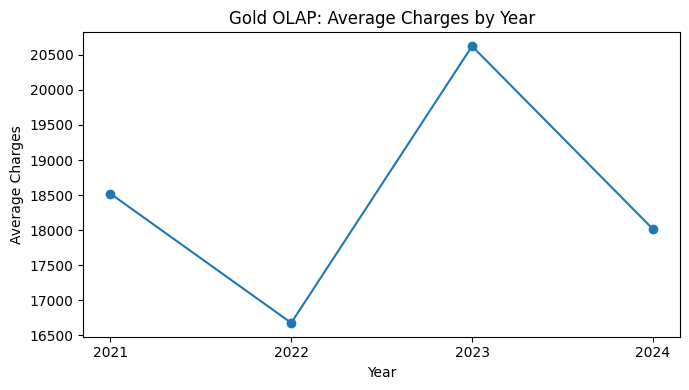

,source_year,policy_count,avg_charges
0,2021,1180,18520.27
1,2022,1074,16677.30
2,2023,1231,20623.53
3,2024,1358,18015.94


In [35]:
df_year = con.execute("""
SELECT
    y.source_year,
    COUNT(*) AS policy_count,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_year y
    ON f.year_key = y.year_key
GROUP BY y.source_year
ORDER BY y.source_year;
""").df()

plt.figure(figsize=(7,4))
plt.plot(df_year["source_year"].astype(str), df_year["avg_charges"], marker="o")
plt.title("Gold OLAP: Average Charges by Year")
plt.xlabel("Year")
plt.ylabel("Average Charges")
plt.tight_layout()
plt.show()

df_year

## Cell 26 — OLAP 2: Average charges by region

### What are we doing?
We compare charges across regions.

### Why are we doing it?
Geography can affect cost patterns.

### Business value
Supports regional business planning.


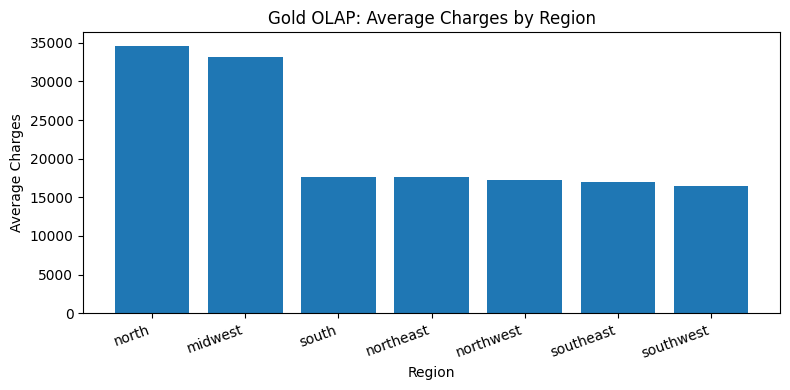

,region,policy_count,avg_charges
0,north,181,34613.05
1,midwest,227,33170.41
2,south,303,17666.19
3,northeast,952,17595.71
4,northwest,1044,17253.45
5,southeast,1177,16954.78
6,southwest,959,16425.00


In [36]:
df_region = con.execute("""
SELECT
    r.region,
    COUNT(*) AS policy_count,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_region r
    ON f.region_key = r.region_key
GROUP BY r.region
ORDER BY avg_charges DESC;
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_region["region"], df_region["avg_charges"])
plt.title("Gold OLAP: Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_region

## Cell 27 — OLAP 3: Average charges by risk profile

### What are we doing?
We compare charges by smoker and BMI group.

### Why are we doing it?
Risk profile is one of the most important dimensions in insurance.

### Business value
Supports risk-based pricing and customer segmentation.


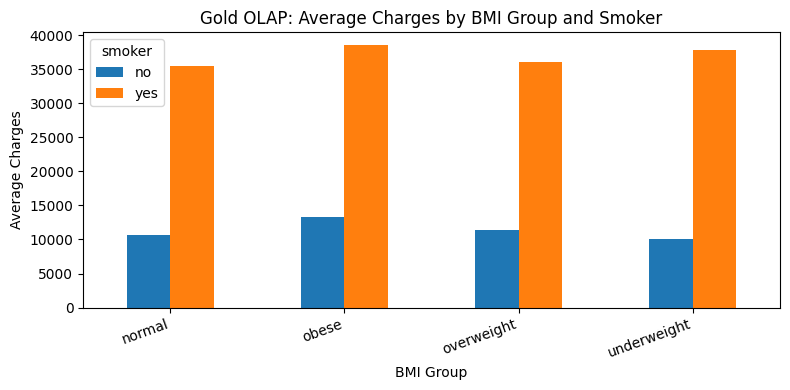

,smoker,bmi_group,policy_count,avg_charges
0,yes,obese,590,38470.62
1,yes,underweight,24,37844.81
2,yes,overweight,382,36062.92
3,yes,normal,216,35491.43
4,no,obese,1909,13343.97
5,no,overweight,1029,11411.24
6,no,normal,584,10715.67
7,no,underweight,109,10061.43


In [37]:
df_risk = con.execute("""
SELECT
    rp.smoker,
    rp.bmi_group,
    COUNT(*) AS policy_count,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_risk_profile rp
    ON f.risk_profile_key = rp.risk_profile_key
GROUP BY rp.smoker, rp.bmi_group
ORDER BY avg_charges DESC;
""").df()

pivot = df_risk.pivot(index="bmi_group", columns="smoker", values="avg_charges")

pivot.plot(kind="bar", figsize=(8,4))
plt.title("Gold OLAP: Average Charges by BMI Group and Smoker")
plt.xlabel("BMI Group")
plt.ylabel("Average Charges")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

df_risk

---
# Final Summary
---

## What We Built

| Layer | Tables | Purpose |
|---|---|---|
| Bronze | `bronze.insurance_raw` | raw messy source data |
| Silver | `step01_dedup`, `step02_standardized`, `rejected_records`, `insurance_clean`, `insurance_enriched` | cleaning, validation, enrichment |
| Gold | dimensions + fact table | star-schema-ready analytics |

## Key Teaching Message

EDA tells us what is wrong.  
Business rules tell us what to do.  
Silver applies the rules.  
Gold makes the data ready for analytics.

> **Never build Gold dashboards directly on Bronze data.**
